# Projeto reconhecimento de dígitos manuscritos

## Pipeline de desenvolvimento de um modelo de Deep Learning

O desenvolvimento de um modelo de Deep Learning segue uma sequência lógica de etapas, conhecida como **pipeline de treinamento**. Cada etapa possui um objetivo específico e prepara o modelo para a etapa seguinte.

Neste notebook seguiremos exatamente esse fluxo utilizando a biblioteca **Keras**, uma das principais APIs para construção de Redes Neurais em Python.

O pipeline pode ser resumido da seguinte forma:

```
Carregar dados
      ↓
Definir arquitetura da rede
      ↓
Compilar o modelo
      ↓
Treinar (Fit)
      ↓
Avaliar (Evaluate)
      ↓
Realizar predições (Predict)
```

Cada uma dessas etapas desempenha um papel fundamental no processo de aprendizagem da rede neural.

| Etapa | Objetivo |
|-------|----------|
| **Carregar dados** | Importar as imagens da base MNIST e seus respectivos rótulos. |
| **Definir modelo** | Construir a arquitetura da rede neural, especificando suas camadas e funções de ativação. |
| **Compilar modelo** | Configurar como a rede aprenderá, definindo o otimizador, a função de perda e as métricas de avaliação. |
| **Fit** | Treinar a rede ajustando seus pesos por meio do algoritmo de Backpropagation. |
| **Evaluate** | Medir o desempenho do modelo utilizando dados nunca vistos durante o treinamento. |
| **Predict** | Utilizar o modelo treinado para classificar novas imagens e analisar suas previsões. |

Embora cada etapa seja implementada por poucas linhas de código, internamente elas envolvem diversos algoritmos matemáticos e computacionais responsáveis pelo aprendizado da rede neural.

Ao longo deste notebook estudaremos cada uma dessas etapas em detalhes, compreendendo tanto sua implementação quanto seu papel dentro do processo completo de treinamento de um modelo de Deep Learning.

## Carregar os dados

Toda aplicação de Machine Learning ou Deep Learning começa pela obtenção dos dados. Nesta etapa carregaremos automaticamente a base MNIST disponibilizada pelo Keras, que já está previamente dividida em conjuntos de treinamento e teste.

Além de importar os dados, também exploraremos sua estrutura, dimensões e distribuição das classes para compreender melhor o problema que será resolvido.

In [1]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [2]:
import tensorflow as tf
from tensorflow import keras

mnist = keras.datasets.mnist

I0000 00:00:1782414140.813233   52842 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782414168.249752   52842 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
mnist

<module 'keras.datasets.mnist' from '/home/rusch/anaconda3/lib/python3.13/site-packages/keras/datasets/mnist/__init__.py'>

In [4]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step 


A base MNIST foi carregada com sucesso e já se encontra dividida em dois subconjuntos:

- **Treinamento (`x_train`, `y_train`)**, utilizado para ajustar os parâmetros da rede neural;
- **Teste (`x_test`, `y_test`)**, utilizado exclusivamente para avaliar o desempenho do modelo após o treinamento.

Essa separação é essencial em Machine Learning, pois permite verificar se o modelo é capaz de **generalizar** o conhecimento adquirido durante o treinamento para exemplos nunca vistos anteriormente.

Nas próximas etapas exploraremos a estrutura desses dados antes de utilizá-los para treinar a rede neural.

In [5]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [6]:
type(x_train[0])

numpy.ndarray

In [7]:
x_train.shape

(60000, 28, 28)

In [8]:
x_train[0][0].shape

(28,)

In [9]:
y_train.shape

(60000,)

In [10]:
y_train[:5]

array([5, 0, 4, 1, 9], dtype=uint8)

As dimensões dos dados confirmam a estrutura esperada da base MNIST.

Cada observação corresponde a uma imagem composta por **28 linhas e 28 colunas**, totalizando:

$[
28 \times 28 = 784
$\]

pixels.

Isso significa que cada imagem pode ser interpretada como um conjunto de **784 atributos numéricos**, os quais serão utilizados pela rede neural para aprender a reconhecer os diferentes dígitos manuscritos.

In [11]:
import numpy as np

np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [12]:
np.unique(y_train, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949]))

In [13]:
contagem = tuple(zip(*np.unique(y_train, return_counts=True)))
contagem

((np.uint8(0), np.int64(5923)),
 (np.uint8(1), np.int64(6742)),
 (np.uint8(2), np.int64(5958)),
 (np.uint8(3), np.int64(6131)),
 (np.uint8(4), np.int64(5842)),
 (np.uint8(5), np.int64(5421)),
 (np.uint8(6), np.int64(5918)),
 (np.uint8(7), np.int64(6265)),
 (np.uint8(8), np.int64(5851)),
 (np.uint8(9), np.int64(5949)))

In [14]:
for par in contagem:
    print(f"{par[0]}: {par[1] / len(y_train) * 100:.2f}%")

0: 9.87%
1: 11.24%
2: 9.93%
3: 10.22%
4: 9.74%
5: 9.04%
6: 9.86%
7: 10.44%
8: 9.75%
9: 9.92%


A inspeção dos rótulos mostra que a base contém exatamente as dez classes esperadas, correspondentes aos dígitos de **0 a 9**.

Além disso, observa-se que a quantidade de exemplos em cada classe é relativamente equilibrada. Esse balanceamento é importante porque reduz a tendência do modelo favorecer determinadas classes durante o treinamento.

Em problemas reais, bases de dados frequentemente apresentam forte desbalanceamento, exigindo técnicas adicionais para evitar vieses no aprendizado.

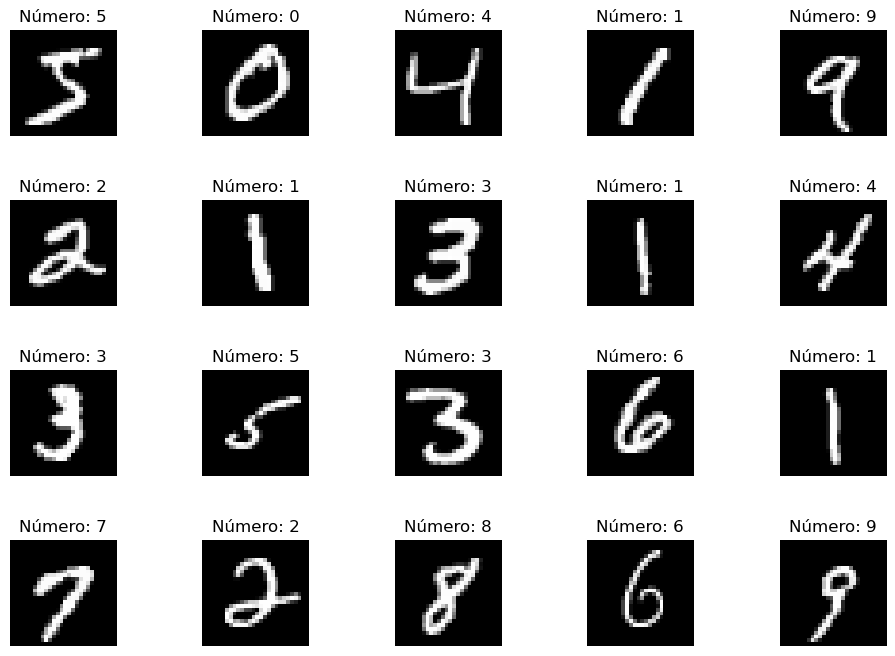

In [15]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(4, 5, figsize=(12, 8))

for i, ax in enumerate(axs.flat):
    ax.imshow(x_train[i], cmap="gray")
    ax.set_title(f"Número: {y_train[i]}")
    ax.axis("off")

fig.subplots_adjust(hspace=0.6)

plt.show()

A inspeção visual permite confirmar que cada imagem representa um dígito manuscrito produzido por diferentes pessoas.

Observa-se uma grande variabilidade na forma de escrita dos números, incluindo diferenças de:

- espessura do traço;
- inclinação;
- tamanho;
- posição na imagem.

Essa diversidade torna o problema mais interessante, pois obriga a rede neural a aprender padrões gerais de cada classe, em vez de simplesmente memorizar exemplos específicos.

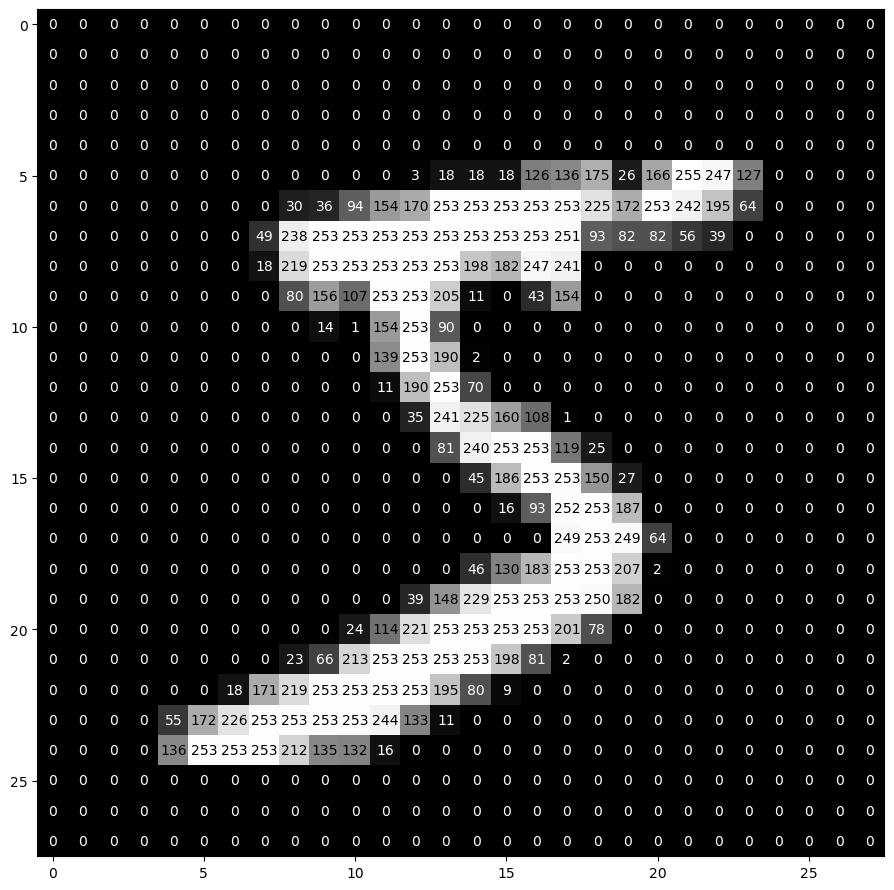

In [16]:
fig, ax = plt.subplots(figsize=(11, 11))

ax.imshow(x_train[0], cmap="gray")

for linha in range(28):
    for coluna in range(28):
        valor = x_train[0][linha][coluna]
        ax.annotate(
            str(valor),
            xy=(coluna, linha),
            color="black" if valor > 100 else "white",
            horizontalalignment="center",
            verticalalignment="center",
        )

plt.show()

Embora enxerguemos visualmente um número manuscrito, o computador interpreta essa imagem apenas como uma matriz de valores numéricos.

Cada elemento da matriz representa a intensidade luminosa de um pixel.

Durante o treinamento, a rede neural não possui qualquer conhecimento prévio sobre o significado desses valores. Seu aprendizado consiste justamente em descobrir quais combinações desses pixels caracterizam cada um dos dez dígitos possíveis.

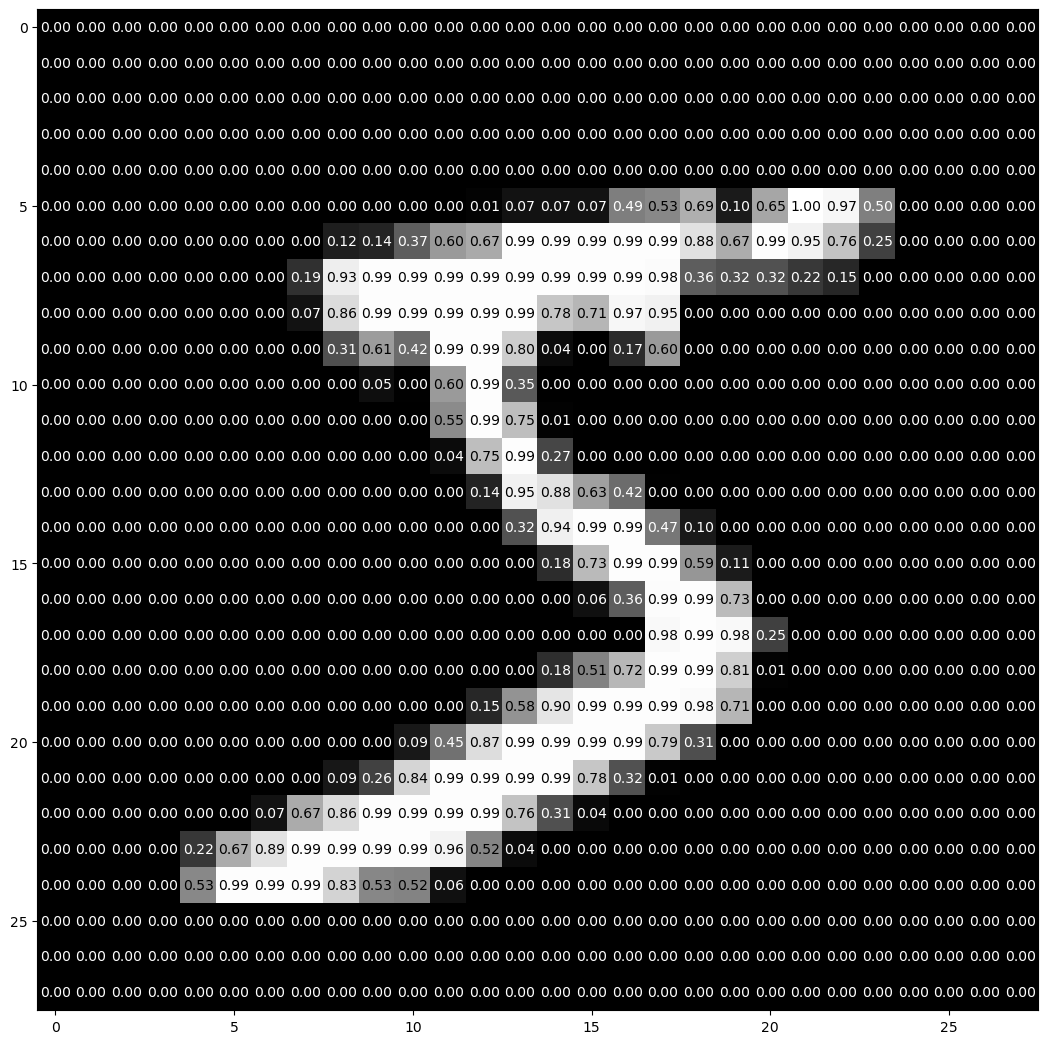

In [17]:
fig, ax = plt.subplots(figsize=(13, 13))

ax.imshow(x_train[0] / 255, cmap="gray")

for linha in range(28):
    for coluna in range(28):
        valor = x_train[0][linha][coluna] / 255
        ax.annotate(
            f"{valor:.2f}",
            xy=(coluna, linha),
            color="black" if valor > 0.5 else "white",
            horizontalalignment="center",
            verticalalignment="center",
        )

plt.show()

A normalização transforma os valores dos pixels do intervalo original $[0, 255$\] para o intervalo $[0, 1$\].

Esse procedimento melhora significativamente o treinamento da rede neural. Quando todas as variáveis possuem escalas semelhantes, o algoritmo de otimização converge de forma mais rápida, estável e eficiente, reduzindo problemas numéricos durante o cálculo dos gradientes.

## Definir o modelo

Após conhecer os dados, o próximo passo consiste em definir a arquitetura da Rede Neural Artificial.

Nesta etapa especificamos:

- o formato da entrada;
- as camadas da rede;
- o número de neurônios em cada camada;
- as funções de ativação utilizadas.

Essa arquitetura determina como a informação será processada desde os pixels da imagem até a classificação final dos dígitos.

https://www.tensorflow.org/api_docs/python/tf/keras/layers/Rescaling

https://www.tensorflow.org/api_docs/python/tf/keras/layers/Flatten

In [18]:
model = keras.models.Sequential()

model.add(keras.layers.InputLayer(input_shape=(28, 28)))
model.add(keras.layers.Rescaling(scale=1./255))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(128, activation="relu"))
model.add(keras.layers.Dense(10, activation="softmax"))

model.summary()

/home/rusch/anaconda3/lib/python3.13/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
E0000 00:00:1782414195.001857   52842 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

A arquitetura da rede neural foi construída com sucesso.

A saída apresentada pelo Keras resume todas as camadas do modelo, mostrando:

- formato das entradas e saídas;
- quantidade de neurônios em cada camada;
- número de parâmetros treináveis.

Esses parâmetros correspondem aos pesos e vieses que serão ajustados automaticamente durante o treinamento por meio do algoritmo de Backpropagation.

Neste momento, entretanto, esses parâmetros ainda possuem valores iniciais e a rede não aprendeu absolutamente nada sobre os dígitos da base MNIST.

## Compilar o modelo

Depois que a arquitetura da rede foi construída, é necessário informar ao Keras **como a rede deverá aprender**.

A compilação define três componentes fundamentais:

- o algoritmo de otimização responsável pela atualização dos pesos;
- a função de perda, utilizada para medir o erro da rede;
- as métricas que acompanharão a evolução do treinamento.

Somente após essa configuração o modelo estará pronto para iniciar o processo de aprendizagem.

In [19]:
optimizer = keras.optimizers.Adam()
loss = keras.losses.SparseCategoricalCrossentropy()
metric = keras.metrics.SparseCategoricalAccuracy()

model.compile(optimizer=optimizer, loss=loss, metrics=[metric])

A compilação prepara o modelo para o treinamento.

Nesta etapa definimos:

- o algoritmo de otimização (**Adam**);
- a função de perda (**Sparse Categorical Crossentropy**);
- a métrica de desempenho (**Accuracy**).

Embora nenhuma aprendizagem tenha ocorrido ainda, a rede agora possui todas as informações necessárias para iniciar o processo de ajuste dos seus parâmetros.

## Treinar o modelo (Fit)

O treinamento representa a etapa mais importante do pipeline.

Durante o treinamento, milhares de imagens são apresentadas à rede neural. Para cada imagem, a rede produz uma previsão, calcula o erro cometido e ajusta automaticamente seus pesos por meio do algoritmo de **Backpropagation**.

Esse processo é repetido durante diversas épocas até que o modelo seja capaz de reconhecer corretamente os padrões presentes na base de dados.

## Fit modelo Keras

In [20]:
early_stop = keras.callbacks.EarlyStopping(
    patience=5,
    verbose=1,
    min_delta=1E-4,
)

history = model.fit(
    x_train,
    y_train,
    epochs=100,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
)

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.3932 - sparse_categorical_accuracy: 0.8920 - val_loss: 0.2113 - val_sparse_categorical_accuracy: 0.9400
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.1842 - sparse_categorical_accuracy: 0.9480 - val_loss: 0.1508 - val_sparse_categorical_accuracy: 0.9569
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1324 - sparse_categorical_accuracy: 0.9626 - val_loss: 0.1280 - val_sparse_categorical_accuracy: 0.9625
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.1028 - sparse_categorical_accuracy: 0.9711 - val_loss: 0.1123 - val_sparse_categorical_accuracy: 0.9678
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0837 - sparse_categorical_accuracy: 0.9764 - val_loss: 0.1030 - val_sparse_categorical_accuracy: 0.9700
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0687 - sparse_categorical_accuracy: 0.9812 - val_loss: 0.0947 - val_sparse_categorical_accuracy: 0.9

O treinamento foi concluído.

Durante cada época, a rede percorreu milhares de imagens, calculando previsões, medindo os erros cometidos e atualizando seus pesos internos por meio do algoritmo de **Backpropagation**.

Ao final do treinamento, espera-se observar:

- redução gradual da função de perda (*loss*);
- aumento progressivo da acurácia;
- comportamento semelhante entre treinamento e validação (*val_loss*).

Caso a perda de validação comece a aumentar enquanto a perda de treinamento continua diminuindo, isso pode indicar **overfitting**, situação em que o modelo passa a memorizar o conjunto de treinamento em vez de aprender padrões gerais.

## Avaliar o modelo

Após o treinamento, é necessário verificar se o modelo realmente aprendeu a resolver o problema e se consegue generalizar para imagens que nunca foram vistas anteriormente.

Para isso utilizamos o conjunto de teste, completamente separado do conjunto de treinamento.

As métricas obtidas nesta etapa fornecem uma estimativa do desempenho esperado quando o modelo for utilizado em situações reais.

## Evaluate modelo Keras

In [21]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0816 - sparse_categorical_accuracy: 0.9776


[0.0815516859292984, 0.9775999784469604]

A avaliação utiliza exclusivamente imagens que nunca participaram do treinamento.

Essa etapa fornece uma estimativa mais realista da capacidade de generalização da rede neural.

Uma acurácia elevada no conjunto de teste indica que o modelo conseguiu aprender características relevantes dos dígitos manuscritos e não apenas memorizar os exemplos utilizados durante o treinamento.

## Realizar predições

Com o modelo treinado e avaliado, podemos utilizá-lo para classificar novas imagens.

Nesta etapa observaremos como a rede produz uma distribuição de probabilidades para cada uma das dez classes possíveis e como essa distribuição é convertida na previsão final do dígito manuscrito.

Também analisaremos alguns exemplos de predições para compreender o comportamento do modelo na prática.

## Predict modelo Keras

## Evolução da função de perda (Loss)

Durante o treinamento, a rede neural procura minimizar uma função denominada **função de perda** (*Loss Function*). Essa função quantifica o erro cometido pelo modelo ao comparar suas previsões com os rótulos verdadeiros das imagens.

Ao longo das épocas de treinamento (*epochs*), espera-se que esse erro diminua progressivamente, indicando que a rede está aprendendo padrões cada vez mais representativos dos dígitos manuscritos.

No gráfico a seguir são apresentadas duas curvas:

- **Training Loss:** erro calculado utilizando o conjunto de treinamento;
- **Validation Loss:** erro calculado utilizando o conjunto de validação.

A comparação entre essas duas curvas permite avaliar não apenas a qualidade do aprendizado, mas também a capacidade de generalização do modelo.

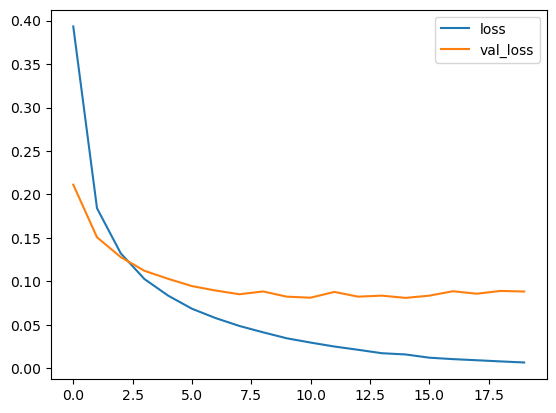

In [22]:
plt.plot(history.history["loss"], label="loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()
plt.show()

### Interpretação dos resultados

Observa-se que tanto a **Training Loss** quanto a **Validation Loss** apresentam uma tendência decrescente ao longo das épocas, indicando que a rede neural está aprendendo padrões relevantes presentes nas imagens da base MNIST.

Entretanto, nota-se que a perda obtida no conjunto de treinamento permanece ligeiramente inferior à observada no conjunto de validação. Esse comportamento é esperado, pois os parâmetros da rede são ajustados diretamente utilizando apenas os dados de treinamento.

Embora exista uma divergência entre as duas curvas, ela permanece relativamente estável ao longo do treinamento. Isso sugere que o modelo ainda mantém uma boa capacidade de generalização, mas já apresenta um **leve indício de overfitting**, uma vez que seu desempenho é sistematicamente melhor nos dados utilizados para o aprendizado.

Em aplicações práticas, esse comportamento pode ser reduzido por técnicas de regularização, como **Dropout**, **Regularização L2**, **Data Augmentation** ou **Early Stopping**, especialmente quando se pretende treinar modelos maiores ou por um número mais elevado de épocas.

## Evolução da acurácia (Accuracy)

Além da função de perda, outra métrica amplamente utilizada em problemas de classificação é a **acurácia** (*Accuracy*).

A acurácia representa a proporção de previsões realizadas corretamente pelo modelo, sendo calculada pela razão entre o número de classificações corretas e o número total de amostras avaliadas.

Enquanto a função de perda mede o erro matemático utilizado durante o treinamento, a acurácia fornece uma medida mais intuitiva do desempenho do modelo.

No gráfico a seguir são apresentadas:

- **Training Accuracy:** desempenho obtido sobre o conjunto de treinamento;
- **Validation Accuracy:** desempenho obtido sobre o conjunto de validação.

A análise conjunta dessas curvas permite acompanhar a evolução do aprendizado ao longo das épocas.

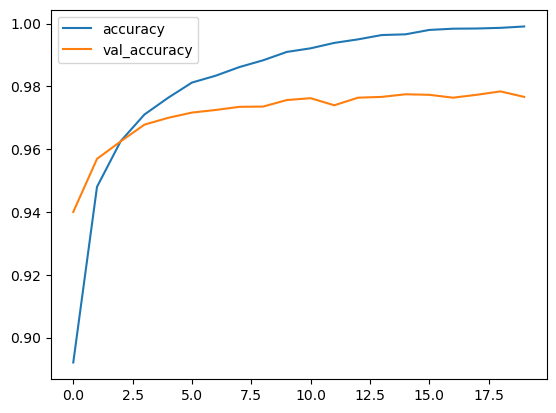

In [23]:
plt.plot(history.history["sparse_categorical_accuracy"], label="accuracy")
plt.plot(history.history["val_sparse_categorical_accuracy"], label="val_accuracy")
plt.legend()
plt.show()

O gráfico da acurácia mostra que o desempenho do modelo aumenta rapidamente durante as primeiras épocas, evidenciando que a rede neural aprende de forma eficiente as características que distinguem os diferentes dígitos manuscritos.

Observa-se também que a **Training Accuracy** permanece ligeiramente superior à **Validation Accuracy** durante praticamente todo o treinamento. Essa diferença é natural, pois o modelo é otimizado diretamente sobre o conjunto de treinamento.

Entretanto, a existência dessa diferença também indica que o modelo se adapta melhor aos dados utilizados para ajustar seus parâmetros do que aos dados de validação. Como essa divergência permanece relativamente pequena e não cresce de forma acentuada ao longo das épocas, ela deve ser interpretada como um **leve sinal de overfitting**, e não como um problema severo de generalização.

Em outras palavras, o modelo demonstra excelente desempenho na tarefa de classificação da base MNIST, embora já apresente o comportamento esperado de uma rede neural que começa a se especializar nos exemplos de treinamento. Em problemas mais complexos, esse comportamento costuma ser monitorado cuidadosamente para evitar que a capacidade de generalização seja comprometida.

> **Observação**
>
> É importante destacar que uma pequena diferença entre as curvas de treinamento e validação é comum em modelos de Deep Learning e, por si só, não caracteriza um problema grave de overfitting. Esse fenômeno passa a ser preocupante quando a diferença entre as curvas cresce continuamente ao longo das épocas, indicando que o modelo está memorizando o conjunto de treinamento em vez de aprender padrões gerais capazes de serem aplicados a novos dados.

In [24]:
x_test[0].shape

(28, 28)

In [25]:
np.expand_dims(x_test[0], axis=0).shape

(1, 28, 28)

In [26]:
model.predict(np.expand_dims(x_test[0], axis=0))[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step


array([9.4520487e-08, 8.4996643e-08, 5.6191857e-07, 5.1692175e-04,
       1.8786477e-13, 1.1123240e-08, 8.9295601e-13, 9.9945539e-01,
       6.5102408e-06, 2.0262067e-05], dtype=float32)

A etapa de predição demonstra como o modelo treinado é utilizado na prática.

Em vez de retornar diretamente um número, a rede neural produz uma distribuição de probabilidades para as dez classes possíveis.

A previsão final corresponde à classe que apresenta a maior probabilidade, representando a hipótese considerada mais provável pelo modelo para a imagem analisada.

Essa abordagem permite avaliar não apenas a classificação final, mas também o grau de confiança associado à decisão da rede neural.

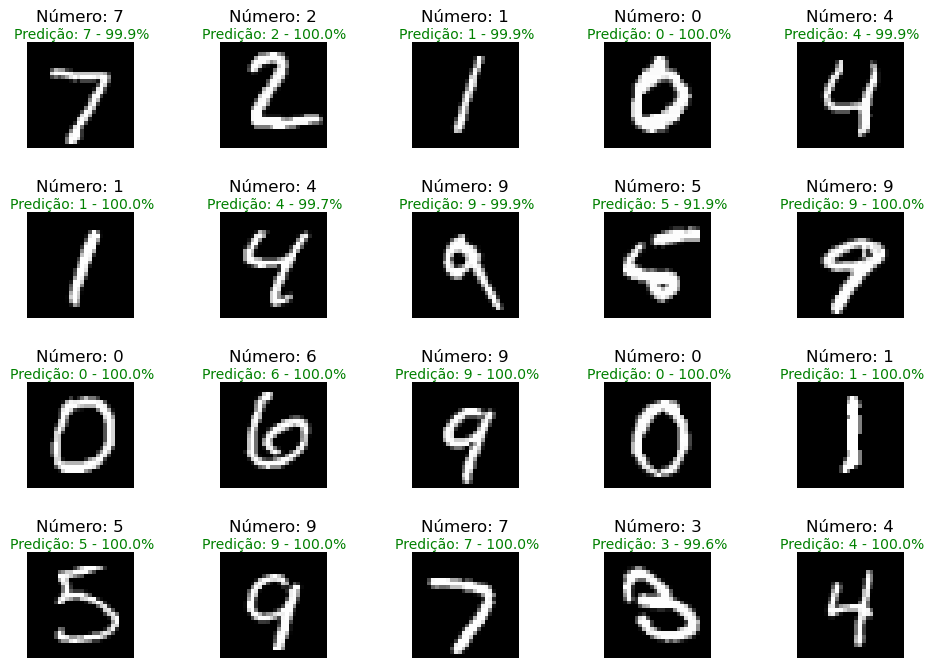

In [27]:
fig, axs = plt.subplots(4, 5, figsize=(12, 8))

for i, ax in enumerate(axs.flat):
    ax.imshow(x_test[i], cmap="gray")
    ax.set_title(f"Número: {y_test[i]}", pad=15)
    ax.axis("off")
    pred = model.predict(np.expand_dims(x_test[i], axis=0), verbose=0)[0]
    ax.text(
        14,
        -2.5,
        f"Predição: {pred.argmax()} - {pred.max():.1%}",
        color="green" if pred.argmax() == y_test[i] else "red",
        verticalalignment="center",
        horizontalalignment="center",
    )

fig.subplots_adjust(hspace=0.6)

plt.show()

https://www.tensorflow.org/api_docs/python/tf/keras/utils/load_img

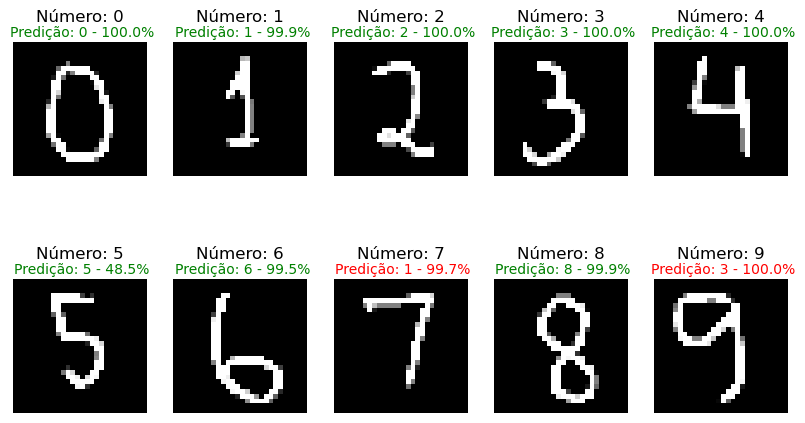

In [37]:
from pathlib import Path

test_images_dir = Path("./data/test_images1")

fig, axs = plt.subplots(2, 5, figsize=(10, 5))

all_pred = {}

for i, (img, ax) in enumerate(zip(sorted(test_images_dir.glob("*.png")), axs.flat)):
    
    name = img.name.split(".")[0]
    
    img = keras.preprocessing.image.load_img(
        img, target_size=(28, 28), color_mode="grayscale"
    )
    img_array = keras.preprocessing.image.img_to_array(img)
    img_array = 255 - img_array
    img_array = tf.expand_dims(img_array, 0)
    
    pred = model.predict(img_array, verbose=0)
    all_pred[name] = pred

    ax.imshow(img_array[0], cmap="gray")
    ax.set_title(f"Número: {name}", pad=15)
    ax.axis("off")
    ax.text(
        14,
        -2.5,
        f"Predição: {pred.argmax()} - {pred.max():.1%}",
        color="green" if str(pred.argmax()) == name else "red",
        verticalalignment="center",
        horizontalalignment="center",
    )

fig.subplots_adjust(hspace=0.6)

plt.show()

In [38]:
all_pred["5"]

array([[1.7277919e-06, 4.1351715e-04, 1.1543648e-05, 9.5384285e-02,
        6.3139574e-08, 4.8538971e-01, 1.9334283e-02, 1.2980733e-08,
        3.9946380e-01, 1.0374521e-06]], dtype=float32)

In [39]:
all_pred["6"]

array([[7.9097767e-08, 3.7199154e-16, 1.0820946e-05, 2.7581265e-10,
        9.2038573e-07, 1.0920730e-03, 9.9495810e-01, 4.8073734e-10,
        3.9381292e-03, 2.3285023e-09]], dtype=float32)

In [40]:
all_pred["7"]

array([[4.3778925e-08, 9.9708933e-01, 2.1600265e-03, 7.4854761e-04,
        7.8236562e-10, 1.6176197e-09, 2.4265651e-10, 1.9609654e-07,
        1.8759628e-06, 7.3113204e-10]], dtype=float32)

A comparação entre os dígitos reais e as previsões permite avaliar qualitativamente o desempenho da rede neural.

Na maior parte das imagens observa-se concordância entre o rótulo verdadeiro e a classe prevista, indicando que o modelo aprendeu corretamente os padrões característicos de cada dígito.

Os erros eventualmente observados costumam ocorrer em imagens cuja escrita apresenta ambiguidades, traços incompletos ou formatos pouco convencionais, como, por exemplo, o dígito $7$ que foi classificado como dígito $1$, com probabilidade de $99.7\%$. Mesmo para seres humanos, alguns desses exemplos podem ser difíceis de classificar.

Essa análise qualitativa complementa as métricas quantitativas apresentadas anteriormente, oferecendo uma visão mais intuitiva do comportamento do modelo em situações reais. Essas situações representam desafios naturais para qualquer sistema de reconhecimento de padrões. Investigaremos, a seguir, a possibilidade de overfitting aplicando fine-tuning no modelo por meio do `keras tuner`.  

# Conclusões

Neste notebook implementamos o pipeline completo de treinamento de uma Rede Neural Artificial utilizando a base MNIST.

Ao longo das etapas realizamos:

- carregamento e inspeção dos dados;
- definição da arquitetura da rede;
- compilação do modelo;
- treinamento por meio do algoritmo de Backpropagation;
- avaliação da capacidade de generalização;
- realização de predições sobre novas imagens.

Os resultados demonstram que mesmo uma arquitetura relativamente simples é capaz de aprender padrões complexos presentes em imagens manuscritas, alcançando elevada acurácia na tarefa de classificação.

Nos próximos notebooks utilizaremos esse primeiro modelo como ponto de partida para explorar arquiteturas mais sofisticadas e técnicas capazes de melhorar ainda mais o desempenho da rede neural.